In [1]:
# All imports required for this project
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Load the datasets
df = pd.read_csv("/Users/evansmith/Desktop/ds-studio-ii/Project 2/Train.csv")
test_df = pd.read_csv("/Users/evansmith/Desktop/ds-studio-ii/Project 2/Test.csv")

In [3]:
# See how many rows and columns are in the dataframe
df.shape

(3000, 26)

In [4]:
# See what kind of variables is in the dataframe
df.dtypes

Gender                          object
Height (cm)                    float64
Weight (kg)                    float64
Blood Pressure (s/d)            object
Cholesterol Level (mg/dL)      float64
BMI                            float64
Blood Glucose Level (mg/dL)    float64
Bone Density (g/cm²)           float64
Vision Sharpness               float64
Hearing Ability (dB)           float64
Physical Activity Level         object
Smoking Status                  object
Alcohol Consumption             object
Diet                            object
Chronic Diseases                object
Medication Use                  object
Family History                  object
Cognitive Function             float64
Mental Health Status            object
Sleep Patterns                  object
Stress Levels                  float64
Pollution Exposure             float64
Sun Exposure                   float64
Education Level                 object
Income Level                    object
Age (years)              

In [5]:
# See the ages in the dataframe
df["Age (years)"].value_counts().sort_index()

Age (years)
18    48
19    39
20    26
21    25
22    36
      ..
85    33
86    48
87    33
88    38
89    48
Name: count, Length: 72, dtype: int64

In [6]:
# See how many null values are in the entire dataframe
df.isnull().sum().sum()

np.int64(5776)

In [7]:
# Split up BP into Systolic and Diastolic and then drop the original column
df["Systolic BP"] = df["Blood Pressure (s/d)"].str.split("/").str[0].astype(float)
df["Diastolic BP"] = df["Blood Pressure (s/d)"].str.split("/").str[1].astype(float)
df.drop(columns=["Blood Pressure (s/d)"], inplace=True)

In [8]:
# Create a copy of the dataframe and convert string variables to numerical values
df_copy = df.copy()

df_copy["Gender"] = df_copy["Gender"].map({"Male": 0, "Female": 1})
df_copy["Physical Activity Level"] = df_copy["Physical Activity Level"].map({"Low": 0, "Moderate": 1, "High": 2})
df_copy["Smoking Status"] = df_copy["Smoking Status"].map({"Never": 0, "Former": 1, "Current": 2})
df_copy["Alcohol Consumption"] = df_copy["Alcohol Consumption"].map({"None": 0, "Occasional": 1, "Frequent": 2})
df_copy["Diet"] = df_copy["Diet"].map({"Vegetarian": 0, "Low-carb": 1, "Balanced": 2, "High-fat": 3})
df_copy["Medication Use"] = df_copy["Medication Use"].map({"None": 0, "Occasional": 1, "Regular": 2})
df_copy["Mental Health Status"] = df_copy["Mental Health Status"].map({"Poor": 0, "Fair": 1, "Good": 2, "Excellent": 3})
df_copy["Sleep Patterns"] = df_copy["Sleep Patterns"].map({"Normal": 0, "Insomnia": 1, "Excessive": 2})
df_copy["Education Level"] = df_copy["Education Level"].map({"None": 0, "High School": 1, "Undergraduate": 2, "Postgraduate": 3})
df_copy["Income Level"] = df_copy["Income Level"].map({"Low": 0, "Medium": 1, "High": 2})

In [9]:
# Turn Family History and Chronic Diseases into either true or false
df_copy = pd.get_dummies(df_copy, columns=["Family History", "Chronic Diseases"])

In [10]:
# Check the new dataset
df_copy.head()

,Gender,Height (cm),Weight (kg),Cholesterol Level (mg/dL),BMI,Blood Glucose Level (mg/dL),Bone Density (g/cm²),Vision Sharpness,Hearing Ability (dB),Physical Activity Level,...,Income Level,Age (years),Systolic BP,Diastolic BP,Family History_Diabetes,Family History_Heart Disease,Family History_Hypertension,Chronic Diseases_Diabetes,Chronic Diseases_Heart Disease,Chronic Diseases_Hypertension
0,0,171.148359,86.185197,259.465814,29.423017,157.652848,0.132868,0.200000,58.786198,1,...,1,89,151.0,109.0,False,False,False,False,False,False
1,0,172.946206,79.641937,263.630292,26.626847,118.507805,0.629534,0.267312,54.635270,0,...,1,77,134.0,112.0,False,True,False,False,False,True
2,1,155.945488,49.167058,207.846206,20.217553,143.587550,0.473487,0.248667,54.564632,1,...,1,70,160.0,101.0,False,False,True,False,False,True
3,1,169.078298,56.017921,253.283779,19.595270,137.448581,1.184315,0.513818,79.722963,1,...,0,52,133.0,94.0,False,False,True,True,False,False
4,1,163.758355,73.966304,236.119899,27.582078,145.328695,0.434562,0.306864,52.479469,0,...,2,79,170.0,106.0,False,False,False,False,False,False


In [11]:
# Set X and y variables base on what we are predicting and then drop that column so it does not influcen the model
X = df_copy.drop(columns = ["Age (years)"])
y = df_copy["Age (years)"]

In [12]:
# Train the data by a 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [13]:
# Check to make sure it was train appropriately
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (2400, 30)
X_test (600, 30)
y_train (2400,)
y_test (600,)


In [14]:
# Create the model
clf = tree.DecisionTreeRegressor()

In [15]:
# Fit the model
clf = clf.fit(X_train, y_train)

In [16]:
# Based on the test set how many times the model was correct at predicting age
clf.score(X_test, y_test)

0.84930273690437

In [17]:
# What my models predicts based on the tested age
predicted = clf.predict(X_test)

In [18]:
# Find the RMSE and R2 score which is the standard deviation of predicted error, so the number is how off the predicted age is high nor low
# The R2 is precentage of variance explained by the model, so basically the RMSE as a precentage
mse = mean_squared_error(y_test, predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predicted)
print("RMSE:", rmse)
print("R2:", r2)

RMSE: 7.858434958692475
R2: 0.84930273690437


In [19]:
# Tells us the infomation from the basic regressor
DecisionTreeRegressor?

Init signature:
DecisionTreeRegressor(
    *,
    criterion='squared_error',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree regressor.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"squared_error", "friedman_mse", "absolute_error",             "poisson"}, default="squared_error"
    The function to measure the quality of a split. Supported criteria
    are "squared_error" for the mean squared error, which is equal to
    variance reduction as feature selection criterion and minimizes the L2
    loss using the mean of each terminal node, "friedman_mse", which uses
    mean squared error with Friedman's improvement score for potential
    splits, "absolute_error" for the mean absolute error, which minim

In [20]:
# How far into the decision tree we will go, the average is about 2 and 4 but this goes deeper at 2 5 10, none.
depths = [2, 5, 10, None]
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Max depth = {depth}, RMSE = {rmse: .4f}, R2 = {r2: .4f}")

Max depth = 2, RMSE =  8.5478, R2 =  0.8217
Max depth = 5, RMSE =  6.4838, R2 =  0.8974
Max depth = 10, RMSE =  7.3237, R2 =  0.8691


Max depth = None, RMSE =  7.7975, R2 =  0.8516


In [21]:
# Chart of the top 20 values comparing actual and predicted age
pd.DataFrame({
    "Predicted": predicted[:20],
    "Actual": y[:20].to_numpy()
})

,Predicted,Actual
0,75.0,89
1,53.0,77
2,47.0,70
3,65.0,52
4,43.0,79
5,34.0,29
6,60.0,76
7,41.0,26
8,25.0,50
9,65.0,77


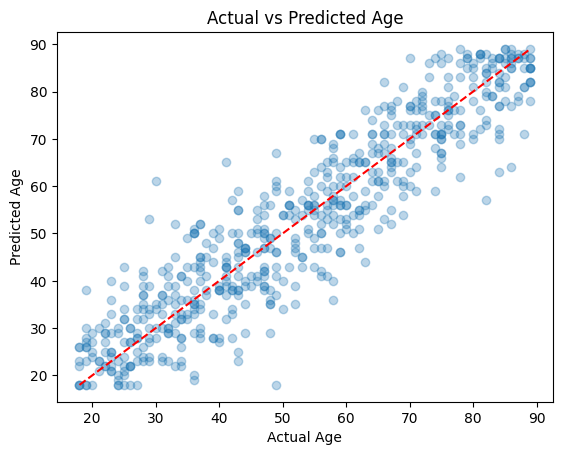

In [22]:
# Using the prediction above this maps the actualy age vs the predicted age with a line of best fit
plt.scatter(y_test, predicted, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age")
plt.show()

In [23]:
# Creates a feature importance to see which variables are driving the predictions
fi = clf.feature_importances_ 
fi = pd.Series(data = fi, index = X.columns) 
fi.sort_values(ascending=False, inplace=True)
print(fi)

Bone Density (g/cm²)              0.885975
Vision Sharpness                  0.046982
Hearing Ability (dB)              0.011115
Systolic BP                       0.006396
Diastolic BP                      0.005698
Blood Glucose Level (mg/dL)       0.004727
Cholesterol Level (mg/dL)         0.004077
Cognitive Function                0.003991
Sun Exposure                      0.003864
Pollution Exposure                0.003237
Weight (kg)                       0.002723
Stress Levels                     0.002694
Height (cm)                       0.002655
BMI                               0.002536
Smoking Status                    0.001724
Alcohol Consumption               0.001638
Income Level                      0.001319
Mental Health Status              0.001060
Physical Activity Level           0.001057
Family History_Diabetes           0.001050
Education Level                   0.000973
Medication Use                    0.000938
Diet                              0.000763
Sleep Patte

/var/folders/87/k687kh2n1r377mqzh_gtkssr0000gn/T/ipykernel_41071/2304383038.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


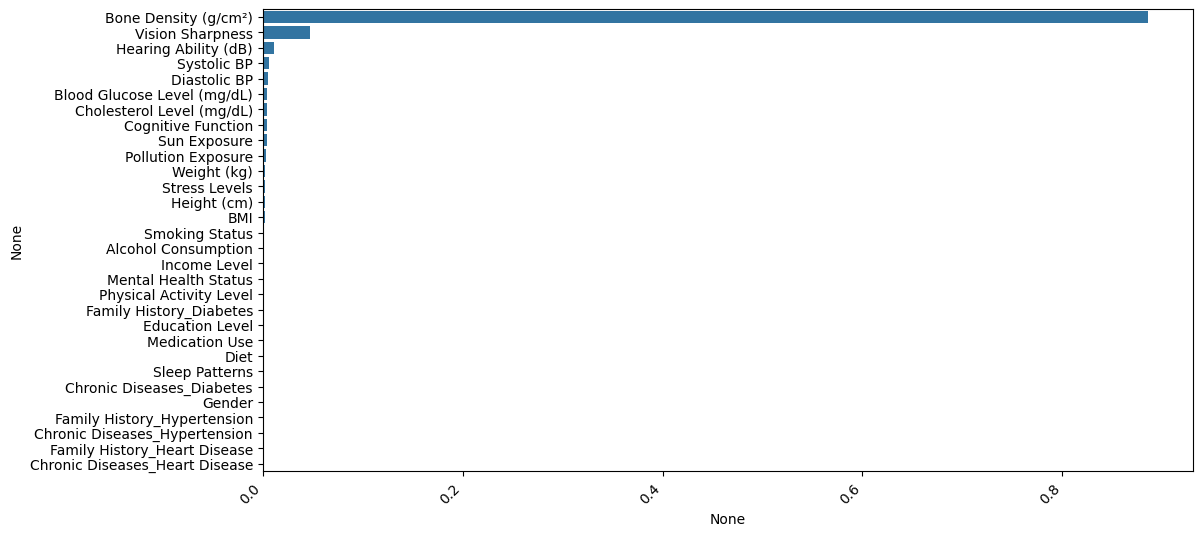

In [24]:
# Plotted the created feature importances from above 
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

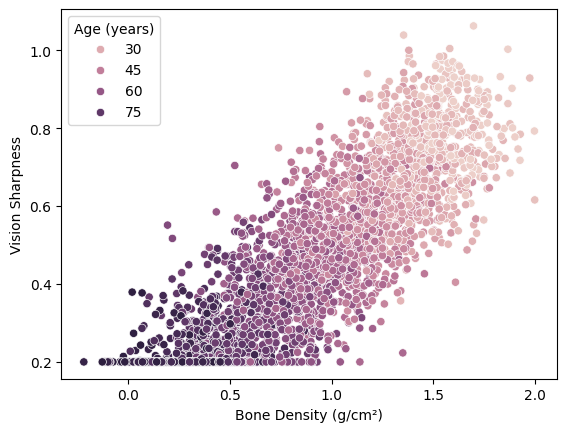

In [25]:
# Created a scatterplot of the top 2 feature importances with the age to see the correlation
sns.scatterplot(data=df_copy, x='Bone Density (g/cm²)', y='Vision Sharpness', hue = "Age (years)",)
plt.show()

# Part 2: Taking out non impactful variables (variables that have little to no correlation in predicting age)

In [26]:
# Creates a new data frame taking out non-impactful variables in my opinion from the copy in part 1
df_copy1 = df_copy.copy()
df_copy1.drop(columns=["Gender", "Height (cm)", "Weight (kg)", "BMI"], inplace=True)

In [27]:
# Creates the X and y variables to predict age
Z = df_copy1.drop(columns = ["Age (years)"])
w = df_copy1["Age (years)"]

In [28]:
# Trains the new dataframe and new vaiables on a 80/20 train/test split
Z_train, Z_test, w_train, w_test = train_test_split(Z, w, test_size = 0.2, random_state=42)

In [29]:
# Checks to make sure it was 80/20
print("Z_train", Z_train.shape)
print("Z_test", Z_test.shape)
print("w_train", w_train.shape)
print("w_test", w_test.shape)

Z_train (2400, 26)
Z_test (600, 26)
w_train (2400,)
w_test (600,)


In [30]:
# Creates a new model based on the new dataframe and variables
clf1 = tree.DecisionTreeRegressor()

In [31]:
# Fits the new model
clf1 = clf1.fit(Z_train, w_train)

In [32]:
# Based on the test set how many times the model was correct at predicting age
clf1.score(Z_test, w_test)

0.849184791781714

In [33]:
# What my models predicts based on the tested age
predicted1 = clf1.predict(Z_test)

In [34]:
# Find the RMSE and R2 score which is the standard deviation of predicted error, so the number is how off the predicted age is high nor low
# The R2 is precentage of variance explained by the model, so basically the RMSE as a precentage
mse = mean_squared_error(w_test, predicted1)
rmse = np.sqrt(mse)
r2 = r2_score(w_test, predicted1)
print("RMSE:", rmse)
print("R2:", r2)

RMSE: 7.861509609059404
R2: 0.849184791781714


In [35]:
# How far into the decision tree we will go, the average is about 2 and 4 but this goes deeper at 2 5 10, none.
depths = [2, 5, 10, None]
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(Z_train, w_train)

    y_pred = model.predict(Z_test)
    mse = mean_squared_error(w_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(w_test, y_pred)

    print(f"Max depth = {depth}, RMSE = {rmse: .4f}, R2 = {r2: .4f}")

Max depth = 2, RMSE =  8.5478, R2 =  0.8217
Max depth = 5, RMSE =  6.4838, R2 =  0.8974
Max depth = 10, RMSE =  7.0825, R2 =  0.8776
Max depth = None, RMSE =  7.8691, R2 =  0.8489


In [36]:
# Chart of the top 20 values comparing actual and predicted age
pd.DataFrame({
    "Predicted": predicted1[:20],
    "Actual": w_test[:20].to_numpy()
})

,Predicted,Actual
0,81.0,67
1,52.0,59
2,47.0,52
3,61.0,67
4,50.0,49
5,34.0,25
6,60.0,49
7,41.0,49
8,24.0,23
9,65.0,63


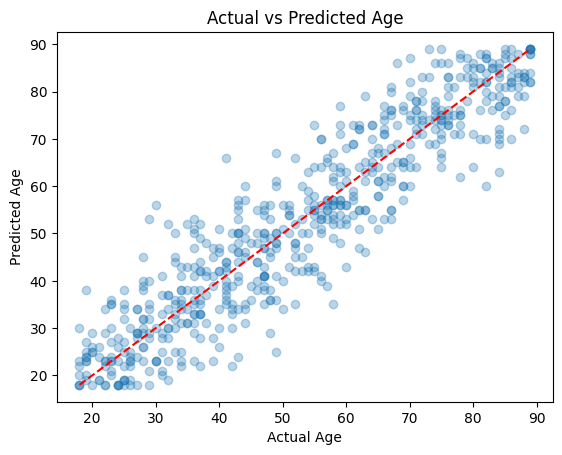

In [37]:
# Plots the predicted vs actual age
plt.scatter(w_test, predicted1, alpha=0.3)
plt.plot([w_test.min(), w_test.max()], [w_test.min(), w_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age")
plt.show()

In [38]:
# Creates a feature importance to see which variables are driving the predictions 
fi1= clf1.feature_importances_ 
fi1 = pd.Series(data = fi1, index = Z.columns) 
fi1.sort_values(ascending=False, inplace=True)
print(fi1)

Bone Density (g/cm²)              0.886623
Vision Sharpness                  0.047941
Hearing Ability (dB)              0.011799
Diastolic BP                      0.007090
Systolic BP                       0.006201
Blood Glucose Level (mg/dL)       0.005012
Cholesterol Level (mg/dL)         0.004465
Pollution Exposure                0.004437
Cognitive Function                0.004351
Sun Exposure                      0.004033
Stress Levels                     0.003338
Smoking Status                    0.002065
Alcohol Consumption               0.001903
Income Level                      0.001410
Mental Health Status              0.001367
Education Level                   0.001032
Family History_Diabetes           0.001027
Sleep Patterns                    0.001022
Diet                              0.000982
Physical Activity Level           0.000873
Family History_Hypertension       0.000791
Chronic Diseases_Diabetes         0.000625
Medication Use                    0.000622
Chronic Dis

/var/folders/87/k687kh2n1r377mqzh_gtkssr0000gn/T/ipykernel_41071/2372812723.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


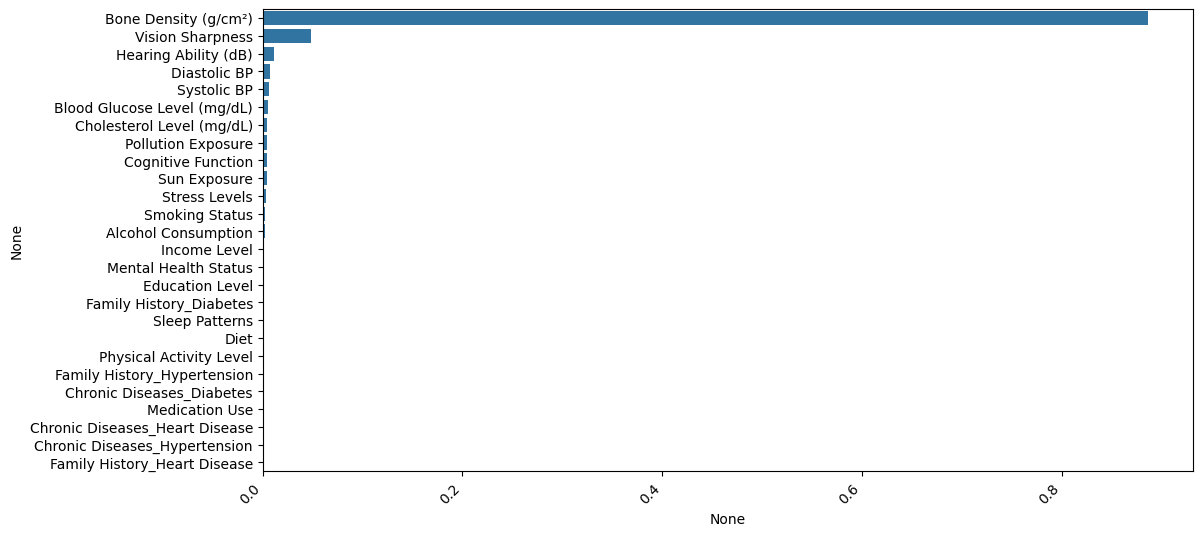

In [39]:
# Plots the feature importances
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi1, y=fi1.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

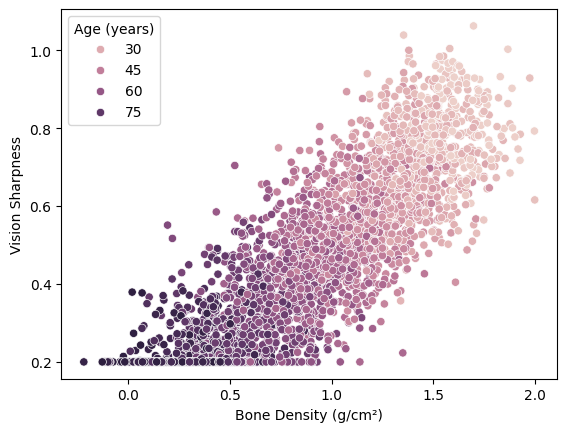

In [40]:
# Created a scatterplot of the top 2 feature importances with the age to see the correlation
sns.scatterplot(data=df, x='Bone Density (g/cm²)', y='Vision Sharpness', hue = "Age (years)")
plt.show()

# Part 3: Testing the model with only factors that influence the model

In [42]:
# Creates a new copy of the DataFrame with only factors that has a greater than 1% feature importance 
df_copy2 = df_copy1[["Bone Density (g/cm²)", "Vision Sharpness", "Hearing Ability (dB)", "Age (years)"]]

In [43]:
# Creates a third model with the new dataframe
clf2 = tree.DecisionTreeRegressor(max_depth=10)

In [44]:
# Creates the dependent variable for the new dataframe
A = df_copy2.drop(columns = ["Age (years)"])
b = df_copy2["Age (years)"]

In [45]:
# Trains the third model
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size = 0.2, random_state=42)

In [46]:
# Fits the third model
clf2 = clf2.fit(A_train, b_train)

In [47]:
# Based on the test set how many times the model was correct at predicting age
clf2.score(A_test, b_test)

0.8778273824319154

In [48]:
# What my models predicts based on the tested age
predicted2 = clf2.predict(A_test)

In [49]:
# Find the RMSE and R2 score which is the standard deviation of predicted error, so the number is how off the predicted age is high nor low
# The R2 is precentage of variance explained by the model, so basically the RMSE as a precentage
mse = mean_squared_error(b_test, predicted2)
rmse = np.sqrt(mse)
r2 = r2_score(b_test, predicted2)
print("RMSE:", rmse)
print("R2:", r2)

RMSE: 7.075714807252691
R2: 0.8778273824319154


In [50]:
# How far into the decision tree we will go, the average is about 2 and 4 but this goes deeper at 2 5 10, none.
depths = [2, 5, 10, None]
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(A_train, b_train)

    y_pred = model.predict(A_test)
    mse = mean_squared_error(b_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(b_test, y_pred)

    print(f"Max depth = {depth}, RMSE = {rmse: .4f}, R2 = {r2: .4f}")

Max depth = 2, RMSE =  8.5478, R2 =  0.8217
Max depth = 5, RMSE =  6.4330, R2 =  0.8990
Max depth = 10, RMSE =  7.1104, R2 =  0.8766
Max depth = None, RMSE =  8.1072, R2 =  0.8396


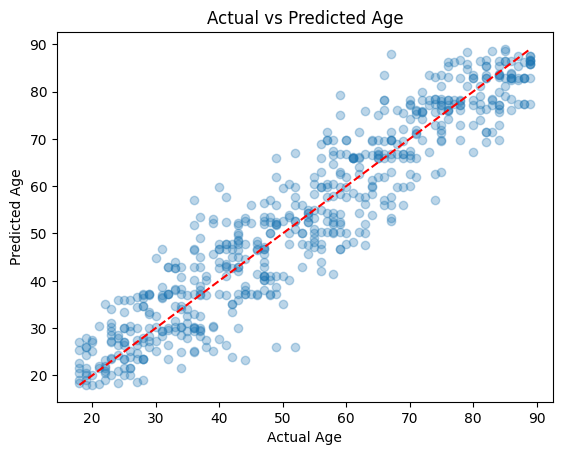

In [51]:
# Plots the predicted vs actual age with a line of best fit
plt.scatter(b_test, predicted2, alpha=0.3)
plt.plot([b_test.min(), b_test.max()], [b_test.min(), b_test.max()], 'r--')  
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age")
plt.show()

In [52]:
# Creates feature importance for the third model
fi2 = clf2.feature_importances_ 
fi2 = pd.Series(data = fi2, index = A.columns) 
fi2.sort_values(ascending=False, inplace=True)
print(fi2)

Bone Density (g/cm²)    0.922523
Vision Sharpness        0.056269
Hearing Ability (dB)    0.021208
dtype: float64


/var/folders/87/k687kh2n1r377mqzh_gtkssr0000gn/T/ipykernel_41071/978754317.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


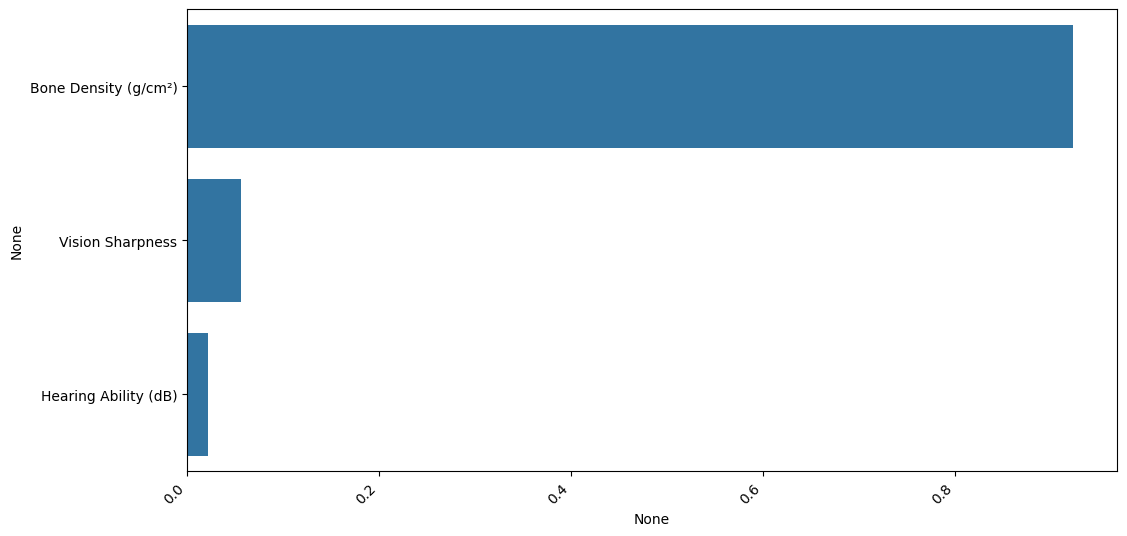

In [53]:
# Plots the third models feature importance
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi2, y=fi2.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

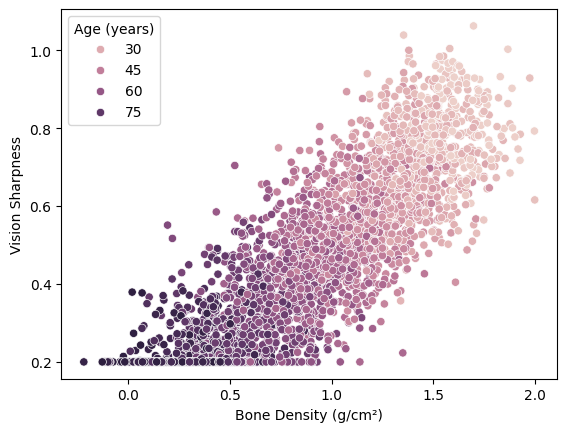

In [54]:
# Creates a scatterplot of the third models most important features with the dependent variables age
sns.scatterplot(data=df, x="Bone Density (g/cm²)", y="Vision Sharpness", hue = "Age (years)")
plt.show()